# PyMC-5 : Modeles de Competences (IRT et DINA)

**Equivalent Infer.NET** : [Infer-5-Skills-IRT](../Infer/Infer-5-Skills-IRT.ipynb)

**Objectifs** :
- Modeliser les competences des etudiants avec l'approche IRT (Item Response Theory)
- Implementer le modele DINA (Deterministic Input, Noisy And gate)
- Estimer les parametres de slip et guess
- Evaluer les modeles avec les courbes ROC
- Comparer l'approche continue (IRT) vs discrete (DINA)

In [1]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from scipy import stats
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print(f"PyMC version: {pm.__version__}")

PyMC version: 5.28.5


## 1. Introduction a l'Evaluation Cognitive

On veut evaluer les competences d'etudiants a partir de leurs reponses a un questionnaire.
Deux approches principales :

- **IRT (Item Response Theory)** : competence continue, chaque question a une difficulte
- **DINA** : competences discretes (maitrise ou non), questions requierent des competences specifiques

## 2. Modele IRT : Theorie de la Reponse a l'Item

Le modele IRT suppose que chaque etudiant a une capacite continue et chaque question
a une difficulte. La probabilite de reponse correcte depend de l'ecart entre capacite et difficulte.

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Capacite | `Variable.GaussianFromMeanAndPrecision(0, 1)` | `pm.Normal('ability', 0, 1)` |
| Difficulte | `Variable.GaussianFromMeanAndPrecision(0, 1)` | `pm.Normal('difficulty', 0, 1)` |
| Discrimination | `Variable.GammaFromShapeAndScale(2, 0.5)` | `pm.Gamma('disc', alpha=2, beta=2)` |
| Reponse | `avantageBruite > 0` (threshold) | `pm.Bernoulli` avec lien probit |

In [2]:
# Donnees : 10 etudiants x 5 questions (1=correct, 0=incorrect)
# Meme donnees que le notebook Infer.NET original
reponses_irt = np.array([
    [1, 1, 1, 0, 0],  # Etudiant 0
    [1, 1, 0, 0, 0],  # Etudiant 1
    [1, 0, 1, 0, 1],  # Etudiant 2
    [0, 1, 1, 1, 0],  # Etudiant 3
    [1, 1, 0, 1, 0],  # Etudiant 4
    [0, 0, 1, 0, 1],  # Etudiant 5
    [1, 1, 1, 1, 1],  # Etudiant 6 (excellent)
    [0, 0, 0, 0, 0],  # Etudiant 7 (en difficulte)
    [1, 0, 1, 0, 0],  # Etudiant 8
    [0, 1, 0, 1, 1],  # Etudiant 9
])

n_etudiants, n_questions = reponses_irt.shape
print(f"Donnees: {n_etudiants} etudiants, {n_questions} questions")
print(f"Taux de reussite moyen: {reponses_irt.mean():.2f}")

Donnees: 10 etudiants, 5 questions
Taux de reussite moyen: 0.52


In [3]:
# Modele IRT avec PyMC
# Equivalent Infer.NET : capacite/ability ~ N(0,1), difficulte ~ N(0,1)
# Lien probit : P(correct) = Phi(ability - difficulty)
# En Infer.NET, on utilise un Gaussienne bruitee et un threshold > 0
# En PyMC, on utilise pm.Potential ou le modele probit directement

with pm.Model() as irt_model:
    # Priors sur les capacites des etudiants
    ability = pm.Normal('ability', mu=0, sigma=1, shape=n_etudiants)
    
    # Priors sur les difficultes des questions
    difficulty = pm.Normal('difficulty', mu=0, sigma=1, shape=n_questions)
    
    # Parametre de discrimination
    discrimination = pm.Gamma('discrimination', alpha=2, beta=2)
    
    # Avantage = capacite - difficulte, pondere par la discrimination
    # Forme (n_etudiants, n_questions)
    advantage = ability[:, None] - difficulty[None, :]
    
    # Probit link : P(correct) = Phi(advantage * discrimination)
    p_correct = pm.math.invprobit(advantage * discrimination)
    
    # Vraisemblance
    responses = pm.Bernoulli('responses', p=p_correct, observed=reponses_irt)
    
    trace_irt = pm.sample(3000, random_seed=42, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [ability, difficulty, discrimination]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 37 seconds.


In [4]:
# Resultats IRT
ability_post = trace_irt.posterior['ability'].values.reshape(-1, n_etudiants)
difficulty_post = trace_irt.posterior['difficulty'].values.reshape(-1, n_questions)
disc_post = trace_irt.posterior['discrimination'].values.flatten()

print("=== Modele IRT ===")
print(f"Discrimination: {disc_post.mean():.2f}")
print()
print("Capacites estimees (moyenne posterior):")
ability_means = ability_post.mean(axis=0)
for i in range(n_etudiants):
    print(f"  Etudiant {i}: {ability_means[i]:+.2f}")
print()
print("Difficultes estimees (moyenne posterior):")
diff_means = difficulty_post.mean(axis=0)
for j in range(n_questions):
    print(f"  Question {j}: {diff_means[j]:+.2f}")

=== Modele IRT ===
Discrimination: 0.30

Capacites estimees (moyenne posterior):
  Etudiant 0: +0.16
  Etudiant 1: -0.19
  Etudiant 2: +0.15
  Etudiant 3: +0.15
  Etudiant 4: +0.15
  Etudiant 5: -0.16
  Etudiant 6: +0.84
  Etudiant 7: -0.86
  Etudiant 8: -0.18
  Etudiant 9: +0.15

Difficultes estimees (moyenne posterior):
  Question 0: -0.26
  Question 1: -0.26
  Question 2: -0.26
  Question 3: +0.28
  Question 4: +0.27


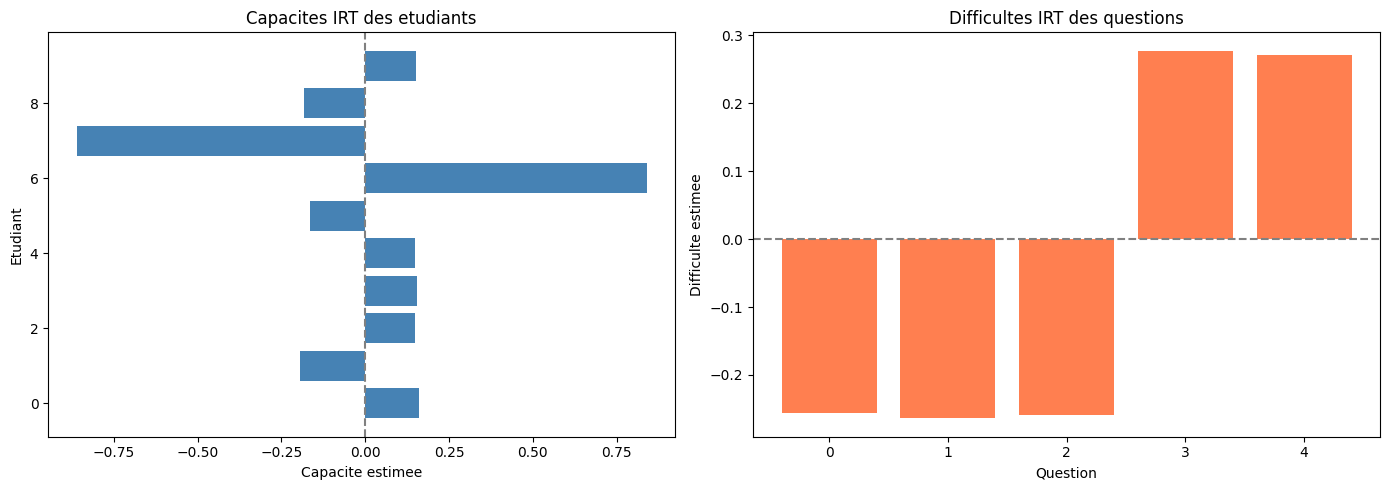

In [5]:
# Visualisation capacites vs difficultes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Capacites des etudiants
axes[0].barh(range(n_etudiants), ability_means, color='steelblue')
axes[0].set_xlabel('Capacite estimee')
axes[0].set_ylabel('Etudiant')
axes[0].set_title('Capacites IRT des etudiants')
axes[0].axvline(0, color='gray', linestyle='--')

# Difficultes des questions
axes[1].bar(range(n_questions), diff_means, color='coral')
axes[1].set_xlabel('Question')
axes[1].set_ylabel('Difficulte estimee')
axes[1].set_title('Difficultes IRT des questions')
axes[1].axhline(0, color='gray', linestyle='--')

plt.tight_layout()
plt.show()

## 3. Evaluation avec la Courbe ROC

La courbe ROC (Receiver Operating Characteristic) mesure la capacite du modele a
distinguer les reponses correctes des incorrectes.

Sampling: [responses]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

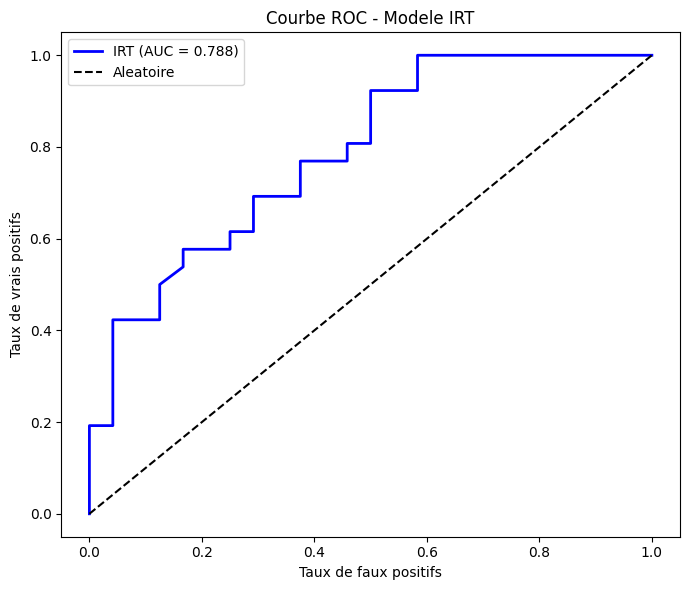

AUC (IRT): 0.788


In [6]:
# Courbe ROC pour le modele IRT
# Probabilites predictives : P(correct) pour chaque paire etudiant-question
with irt_model:
    ppc_irt = pm.sample_posterior_predictive(trace_irt, random_seed=42)

# Probabilites predites (moyenne sur les echantillons)
pred_probs = ppc_irt.posterior_predictive['responses'].values.reshape(-1, n_etudiants, n_questions)
pred_mean = pred_probs.mean(axis=0).flatten()
observed = reponses_irt.flatten()

# Courbe ROC
fpr, tpr, thresholds = roc_curve(observed, pred_mean)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'IRT (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Aleatoire')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbe ROC - Modele IRT')
ax.legend()
plt.tight_layout()
plt.show()

print(f"AUC (IRT): {roc_auc:.3f}")

## 4. Modele DINA (Deterministic Input, Noisy And gate)

Le modele DINA suppose que chaque question requiert un ensemble de competences.
Un etudiant ne peut repondre correctement que s'il maitrise TOUTES les competences requises.

### Architecture Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Competence | `Variable.Bernoulli(0.5)` | `pm.Bernoulli('comp', p=0.5)` |
| Toutes competences | `aC1 & aC2` (AND logique) | `pt.and_` ou produit |
| Slip (faute) | `Variable.Bernoulli(slip)` si competent | `pt.switch` |
| Guess (chance) | `Variable.Bernoulli(guess)` si non-competent | `pt.switch` |
| Q-matrix | Conditions manuelles | Matrice numpy + indexation |

In [7]:
# Donnees DINA : 8 etudiants x 6 questions x 3 competences
# Q-matrix : quelles competences sont requises pour chaque question
Q_matrix = np.array([
    [1, 0, 0],  # Question 0 : competence 1 uniquement
    [0, 1, 0],  # Question 1 : competence 2 uniquement
    [0, 0, 1],  # Question 2 : competence 3 uniquement
    [1, 1, 0],  # Question 3 : competences 1 ET 2
    [0, 1, 1],  # Question 4 : competences 2 ET 3
    [1, 1, 1],  # Question 5 : toutes les competences
])

reponses_dina = np.array([
    [1, 0, 0, 0, 0, 0],  # Etudiant 0
    [1, 1, 0, 0, 0, 0],  # Etudiant 1
    [1, 1, 1, 1, 1, 1],  # Etudiant 2 (maitrise tout)
    [0, 0, 0, 0, 0, 0],  # Etudiant 3
    [1, 0, 1, 0, 0, 1],  # Etudiant 4
    [0, 1, 0, 0, 0, 0],  # Etudiant 5
    [1, 1, 0, 1, 0, 0],  # Etudiant 6
    [0, 0, 1, 0, 0, 0],  # Etudiant 7
])

n_etud_dina, n_quest_dina = reponses_dina.shape
n_comp = Q_matrix.shape[1]

print(f"DINA: {n_etud_dina} etudiants, {n_quest_dina} questions, {n_comp} competences")
print(f"Q-matrix:\n{Q_matrix}")

DINA: 8 etudiants, 6 questions, 3 competences
Q-matrix:
[[1 0 0]
 [0 1 0]
 [0 0 1]
 [1 1 0]
 [0 1 1]
 [1 1 1]]


In [8]:
# Modele DINA avec PyMC
# Equivalent Infer.NET : Variable.Bernoulli(0.5) par competence
# puis AND logique pour determiner la maitrise de la question

with pm.Model() as dina_model:
    # Priors sur les competences de chaque etudiant
    # alpha[i, k] = 1 si l'etudiant i maitrise la competence k
    alpha = pm.Bernoulli('alpha', p=0.5, shape=(n_etud_dina, n_comp))
    
    # Parametres de slip et guess
    slip = pm.Beta('slip', alpha=2, beta=18, shape=n_quest_dina)
    guess = pm.Beta('guess', alpha=3, beta=12, shape=n_quest_dina)
    
    # Pour chaque etudiant-question, determiner si TOUTES les competences sont maitrisees
    # Q_matrix[j, k] = 1 si la question j requiert la competence k
    # mastery[i, j] = AND_k(alpha[i,k] * Q[j,k]) pour les competences requises
    
    # Competences par etudiant-question : (n_etud, n_quest, n_comp)
    comp_owned = alpha[:, None, :] * Q_matrix[None, :, :]
    
    # Pour chaque question, verifier que toutes les competences requises sont maitrisees
    # mastery = 1 si comp_owned >= Q_matrix pour chaque competence
    mastery = pt.prod(comp_owned + (1 - Q_matrix[None, :, :]), axis=2)
    
    # Probabilite de reponse correcte
    # Si mastery=1 : P(correct) = 1 - slip (petite chance de se tromper)
    # Si mastery=0 : P(correct) = guess (petite chance de deviner)
    p_correct = pt.switch(mastery, 1 - slip[None, :], guess[None, :])
    
    # Vraisemblance
    responses_dina = pm.Bernoulli('responses_dina', p=p_correct, observed=reponses_dina)
    
    trace_dina = pm.sample(3000, random_seed=42, return_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>BinaryGibbsMetropolis: [alpha]


>NUTS: [slip, guess]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 46 seconds.


In [9]:
# Resultats DINA
alpha_post = trace_dina.posterior['alpha'].values.reshape(-1, n_etud_dina, n_comp)
slip_post = trace_dina.posterior['slip'].values.reshape(-1, n_quest_dina)
guess_post = trace_dina.posterior['guess'].values.reshape(-1, n_quest_dina)

# Probabilites de maitrise
alpha_mean = alpha_post.mean(axis=0)

print("=== Modele DINA ===")
print("Probabilites de maitrise des competences:")
comp_names = ['Comp1', 'Comp2', 'Comp3']
for i in range(n_etud_dina):
    comps = ', '.join(f'{comp_names[k]}={alpha_mean[i,k]:.2f}' for k in range(n_comp))
    print(f"  Etudiant {i}: {comps}")

print()
print("Parametres de slip (faute si competent):")
for j in range(n_quest_dina):
    print(f"  Question {j}: slip={slip_post[:,j].mean():.3f}")

print()
print("Parametres de guess (chance si non-competent):")
for j in range(n_quest_dina):
    print(f"  Question {j}: guess={guess_post[:,j].mean():.3f}")

=== Modele DINA ===
Probabilites de maitrise des competences:
  Etudiant 0: Comp1=0.81, Comp2=0.02, Comp3=0.11
  Etudiant 1: Comp1=0.56, Comp2=0.55, Comp3=0.05
  Etudiant 2: Comp1=0.99, Comp2=1.00, Comp3=0.99
  Etudiant 3: Comp1=0.10, Comp2=0.08, Comp3=0.09
  Etudiant 4: Comp1=0.82, Comp2=0.01, Comp3=0.84
  Etudiant 5: Comp1=0.03, Comp2=0.81, Comp3=0.03
  Etudiant 6: Comp1=0.96, Comp2=0.96, Comp3=0.01
  Etudiant 7: Comp1=0.10, Comp2=0.02, Comp3=0.83

Parametres de slip (faute si competent):
  Question 0: slip=0.092
  Question 1: slip=0.091
  Question 2: slip=0.100
  Question 3: slip=0.099
  Question 4: slip=0.096
  Question 5: slip=0.095

Parametres de guess (chance si non-competent):
  Question 0: guess=0.205
  Question 1: guess=0.188
  Question 2: guess=0.165
  Question 3: guess=0.147
  Question 4: guess=0.137
  Question 5: guess=0.182


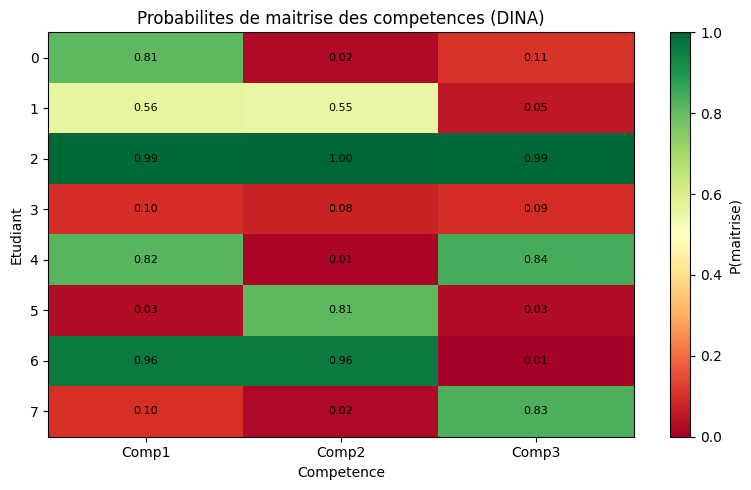

In [10]:
# Visualisation des competences DINA
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
im = ax.imshow(alpha_mean, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xlabel('Competence')
ax.set_ylabel('Etudiant')
ax.set_xticks(range(n_comp))
ax.set_xticklabels(comp_names)
ax.set_title('Probabilites de maitrise des competences (DINA)')
plt.colorbar(im, label='P(maitrise)')

# Annotations
for i in range(n_etud_dina):
    for k in range(n_comp):
        ax.text(k, i, f'{alpha_mean[i,k]:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 5. Estimation avec Priors Informatifs

Les priors informatifs sur slip et guess ameliorent l'estimation quand les donnees
sont limitees. On utilise des Beta concentres autour des valeurs attendues :
- **Slip** : `Beta(2, 18)` — en moyenne 0.1, l'etudiant competent se trompe rarement
- **Guess** : `Beta(3, 12)` — en moyenne 0.2, l'etudiant non-competent a une petite chance

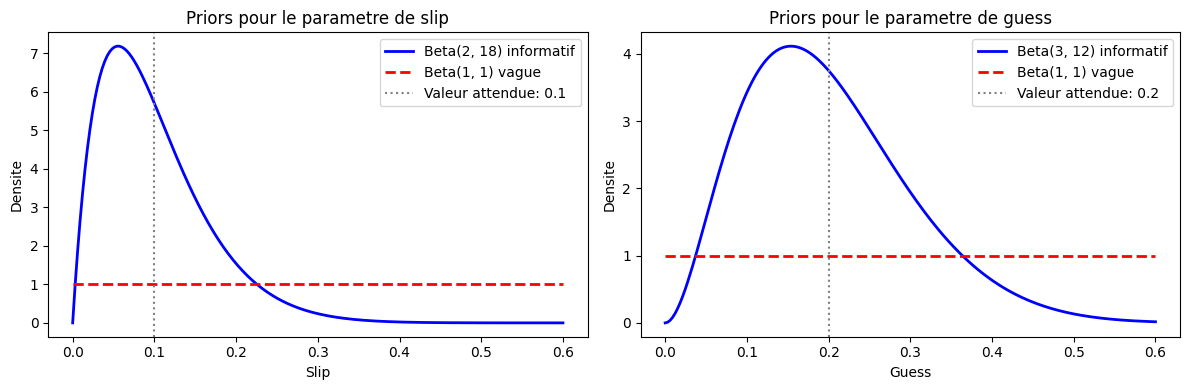

Les priors informatifs concentrent la probabilite autour des valeurs plausibles.
Cela stabilise l'estimation quand les donnees sont limitees (peu d'etudiants).


In [11]:
# Comparaison des priors informatifs vs non-informatifs
x = np.linspace(0, 0.6, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Priors pour slip
slip_info = stats.beta(2, 18)
slip_vague = stats.beta(1, 1)
axes[0].plot(x, slip_info.pdf(x), 'b-', label='Beta(2, 18) informatif', linewidth=2)
axes[0].plot(x, slip_vague.pdf(x), 'r--', label='Beta(1, 1) vague', linewidth=2)
axes[0].axvline(0.1, color='gray', linestyle=':', label='Valeur attendue: 0.1')
axes[0].set_title('Priors pour le parametre de slip')
axes[0].legend()
axes[0].set_xlabel('Slip')
axes[0].set_ylabel('Densite')

# Priors pour guess
guess_info = stats.beta(3, 12)
guess_vague = stats.beta(1, 1)
axes[1].plot(x, guess_info.pdf(x), 'b-', label='Beta(3, 12) informatif', linewidth=2)
axes[1].plot(x, guess_vague.pdf(x), 'r--', label='Beta(1, 1) vague', linewidth=2)
axes[1].axvline(0.2, color='gray', linestyle=':', label='Valeur attendue: 0.2')
axes[1].set_title('Priors pour le parametre de guess')
axes[1].legend()
axes[1].set_xlabel('Guess')
axes[1].set_ylabel('Densite')

plt.tight_layout()
plt.show()

print("Les priors informatifs concentrent la probabilite autour des valeurs plausibles.")
print("Cela stabilise l'estimation quand les donnees sont limitees (peu d'etudiants).")

## 6. Comparaison IRT vs DINA

| Aspect | IRT | DINA |
|--------|-----|------|
| Competence | Continue (nombre reel) | Discrete (maitrise/non-maitrise) |
| Parametres | Capacite, difficulte, discrimination | Competences binaires, slip, guess |
| Logique de reponse | Probit (continue) | AND gate + bruit |
| Priors | Gaussiens | Beta (informatifs) |
| Diagnostic | Position relative | Competences specifiques manquantes |
| Avantage | Granularite | Interpretabilite pedagogique |
| Limite | Difficile d'identifier les lacunes | Hypothese AND stricte |
| Performance Infer.NET | Rapide (EP analytique) | Rapide (message passing) |
| Performance PyMC | NUTS (echantillonnage) | NUTS + CategoricalGibbsMetropolis |

## Exercice 1 : Evaluer un Nouvel Etudiant avec DINA

Un nouvel etudiant repond aux 6 questions du modele DINA.
Ses reponses sont : `[1, 0, 1, 0, 1, 0]`

1. Quelles competences possede-t-il probablement ?
2. Quelle est la probabilite qu'il maitrise la competence 3 ?

**Indices** :
- Reutiliser le modele DINA ci-dessus avec les memes slip/guess
- Ajouter l'etudiant 8 au tableau de donnees
- Examiner `alpha_post[:, 8, :]` pour les probabilites de maitrise

In [12]:
# TODO etudiant : evaluer le nouvel etudiant avec le modele DINA
# Indices :
# - Ajouter les reponses du nouvel etudiant aux donnees existantes
# - Reprendre le modele DINA avec n_etud_dina = 9
# - Examiner les probabilites de maitrise pour l'etudiant 8

print("Exercice a completer")

Exercice a completer


## Exercice 2 : Comparer Deux Classes

On a deux classes d'etudiants qui ont passe le meme questionnaire.
Comparer les niveaux moyens de competence entre les deux classes.

**Indices** :
- Utiliser le modele IRT avec les deux groupes
- Comparer les distributions posterieures des capacites
- Visualiser avec un boxplot ou un violin plot

In [13]:
# TODO etudiant : comparer deux classes
# Donnees pour la classe B
# reponses_classe_b = np.array([...])  # a definir
# Indices :
# - Definir un modele IRT pour chaque classe
# - Comparer ability_means entre les deux classes
# - Utiliser plt.boxplot ou az.plot_posterior pour la comparaison

print("Exercice a completer")

Exercice a completer
